In [3]:
!pip install torch
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn



In [4]:
import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.optim as optim
import torch.nn.functional as F
from sklearn.utils import shuffle
from sklearn import metrics


In [4]:
import pandas as pd

file_path = f'/kaggle/input/datasets/n0g1ong/arpinggg/Spoofing_Dataset.csv'

df = pd.read_csv(file_path)

df.head()

,No.,Time,Source,Destination,Protocol,Length,Info,Label
0,1,0.000000,10.0.2.15,34.120.115.102,TLSv1.2,93,Application Data,Benign
1,2,0.001295,34.120.115.102,10.0.2.15,TCP,60,443 > 36940 [ACK] Seq=1 Ack=40 Win=65535 Len=0,Benign
2,3,0.002404,10.0.2.15,34.120.115.102,TLSv1.2,78,Application Data,Benign
3,4,0.003157,34.120.115.102,10.0.2.15,TCP,60,443 > 36940 [ACK] Seq=1 Ack=64 Win=65535 Len=0,Benign
4,5,0.003963,10.0.2.15,34.120.115.102,TCP,54,"36940 > 443 [FIN, ACK] Seq=64 Ack=1 Win=6291...",Benign


In [5]:
df['Label'].value_counts()


Label
Benign        820
Mallicious    380
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df.drop('Label', axis=1)  
y = df['Label']  


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape - X:", X_train.shape, "y:", y_train.shape)
print("Testing set shape - X:", X_test.shape, "y:", y_test.shape)


Training set shape - X: (960, 7) y: (960,)
Testing set shape - X: (240, 7) y: (240,)


In [9]:
X.describe()

,No.,Time,Length
count,1200.000000,1200.000000,1200.000000
mean,600.500000,147.447252,170.908333
std,346.554469,80.628457,353.191565
min,1.000000,0.000000,42.000000
25%,300.750000,120.183378,42.000000
50%,600.500000,127.245265,54.000000
75%,900.250000,198.828472,76.500000
max,1200.000000,342.531264,1514.000000


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer



target_variable = df['Label']


feature_columns = df.drop('Label', axis=1)


df_cleaned = df.dropna()


categorical_cols = ['Source', 'Destination', 'Protocol']
numerical_cols = ['Time', 'Length']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ]
)


X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned.drop('Label', axis=1),  
    df_cleaned['Label'], 
    test_size=0.2,
    random_state=42
)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print("Cleaned and Preprocessed Dataset:")
print(df_cleaned.head())


Cleaned and Preprocessed Dataset:
   No.      Time          Source     Destination Protocol  Length  \
0    1  0.000000       10.0.2.15  34.120.115.102  TLSv1.2      93   
1    2  0.001295  34.120.115.102       10.0.2.15      TCP      60   
2    3  0.002404       10.0.2.15  34.120.115.102  TLSv1.2      78   
3    4  0.003157  34.120.115.102       10.0.2.15      TCP      60   
4    5  0.003963       10.0.2.15  34.120.115.102      TCP      54   

                                                Info   Label  
0                                   Application Data  Benign  
1   443  >  36940 [ACK] Seq=1 Ack=40 Win=65535 Len=0  Benign  
2                                   Application Data  Benign  
3   443  >  36940 [ACK] Seq=1 Ack=64 Win=65535 Len=0  Benign  
4  36940  >  443 [FIN, ACK] Seq=64 Ack=1 Win=6291...  Benign  


In [11]:
y_test.value_counts()

Label
Benign        156
Mallicious     84
Name: count, dtype: int64

In [36]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/n0g1ong/arpinggg/Spoofing_Test.csv")

df['Label'] = df['Label'].replace("Malicious", "Mallicious")

df.to_csv("/kaggle/working/Spoofing_Testing.csv", index=False)

print("Change Success")

Change Success


# Using Reinforcemnet Learnin(Q-Learning)


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [35]:

file_path = f'/kaggle/input/datasets/n0g1ong/arpinggg/Spoofing_Dataset.csv'

df = pd.read_csv(file_path)

df.head()

,No.,Time,Source,Destination,Protocol,Length,Info,Label
0,1,0.000000,10.0.2.15,34.120.115.102,TLSv1.2,93,Application Data,Benign
1,2,0.001295,34.120.115.102,10.0.2.15,TCP,60,443 > 36940 [ACK] Seq=1 Ack=40 Win=65535 Len=0,Benign
2,3,0.002404,10.0.2.15,34.120.115.102,TLSv1.2,78,Application Data,Benign
3,4,0.003157,34.120.115.102,10.0.2.15,TCP,60,443 > 36940 [ACK] Seq=1 Ack=64 Win=65535 Len=0,Benign
4,5,0.003963,10.0.2.15,34.120.115.102,TCP,54,"36940 > 443 [FIN, ACK] Seq=64 Ack=1 Win=6291...",Benign


In [44]:
import pandas as pd
import numpy as np

# =========================================================
# 1. Q-LEARNING CLASS
# =========================================================
class QLearning:
    def __init__(self, n_actions, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.q_table = np.zeros((0, n_actions))
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.state_dict = {}

    def get_state_index(self, state):
        # Chuyển state thành tuple để làm key ổn định
        state_key = tuple(np.round(state, 4))
        if state_key not in self.state_dict:
            self.state_dict[state_key] = len(self.state_dict)
            self.q_table = np.vstack(
                [self.q_table, np.zeros((1, self.q_table.shape[1]))]
            )
        return self.state_dict[state_key]

    def choose_action(self, state):
        state_index = self.get_state_index(state)

        # epsilon-greedy
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.choice(self.q_table.shape[1])
        else:
            return np.argmax(self.q_table[state_index])

    def update_q_table(self, state, action_index, reward, next_state):
        state_index = self.get_state_index(state)
        next_state_index = self.get_state_index(next_state)

        predict = self.q_table[state_index, action_index]
        target = reward + self.gamma * np.max(self.q_table[next_state_index])

        self.q_table[state_index, action_index] += self.alpha * (target - predict)


# =========================================================
# 2. LOAD DATA
# =========================================================
# df = pd.read_csv("your_file.csv")

# =========================================================
# 3. BỎ NHỮNG CỘT KHÔNG NÊN HỌC THUỘC
#    => để đổi IP khác vẫn detect được
# =========================================================
drop_cols = ['No.', 'Time', 'Label']

# Nếu file có các cột IP thì bỏ luôn
for col in ['Source', 'Destination', 'Src IP', 'Dst IP', 'Source IP', 'Destination IP']:
    if col in df.columns:
        drop_cols.append(col)

features = df.drop(columns=drop_cols, errors='ignore').copy()
labels = df['Label'].copy()

# =========================================================
# 4. MÃ HÓA LABEL
# =========================================================
unique_labels = labels.unique()
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

y = labels.map(label_to_index)

# =========================================================
# 5. CHUYỂN TOÀN BỘ FEATURE SANG SỐ
# =========================================================
# Nếu còn cột object thì ép về số hoặc loại bỏ
for col in features.columns:
    if features[col].dtype == 'object':
        features[col] = pd.factorize(features[col])[0]

features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(0)

# =========================================================
# 6. CHUẨN HÓA DỮ LIỆU
# =========================================================
X = features.values.astype(float)

mean = X.mean(axis=0)
std = X.std(axis=0)
std[std == 0] = 1

X = (X - mean) / std

# =========================================================
# 7. KHỞI TẠO MODEL
# =========================================================
n_actions = len(unique_labels)
q_learning_model = QLearning(
    n_actions=n_actions,
    alpha=0.1,
    gamma=0.9,
    epsilon=0.1
)

# =========================================================
# 8. TRAIN
#    Reward:
#    +1 nếu đoán đúng
#    -1 nếu đoán sai
# =========================================================
episodes = 10

for ep in range(episodes):
    correct_in_episode = 0

    for i in range(len(X) - 1):
        state = X[i]
        next_state = X[i + 1]

        true_action = y.iloc[i]

        predicted_action = q_learning_model.choose_action(state)

        if predicted_action == true_action:
            reward = 1
            correct_in_episode += 1
        else:
            reward = -1

        q_learning_model.update_q_table(
            state=state,
            action_index=predicted_action,
            reward=reward,
            next_state=next_state
        )

    acc_ep = correct_in_episode / (len(X) - 1)
    print(f"Episode {ep+1}/{episodes} - Accuracy tạm thời: {acc_ep*100:.2f}%")

# =========================================================
# 9. ĐÁNH GIÁ CUỐI
# =========================================================
correct_predictions = 0
predictions = []

for i in range(len(X)):
    state = X[i]
    true_action = y.iloc[i]

    predicted_action = q_learning_model.choose_action(state)
    predictions.append(predicted_action)

    if predicted_action == true_action:
        correct_predictions += 1

accuracy = correct_predictions / len(X)
print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")

# =========================================================
# 10. GẮN NHÃN DỰ ĐOÁN VÀO DATAFRAME
# =========================================================
df_result = df.copy()
df_result['Predicted_Label'] = [index_to_label[p] for p in predictions]

print("\nSo sánh nhãn thật và nhãn dự đoán:")
print(df_result[['Label', 'Predicted_Label']].head(20))

Episode 1/10 - Accuracy tạm thời: 87.99%
Episode 2/10 - Accuracy tạm thời: 95.16%
Episode 3/10 - Accuracy tạm thời: 94.75%
Episode 4/10 - Accuracy tạm thời: 93.74%
Episode 5/10 - Accuracy tạm thời: 94.16%
Episode 6/10 - Accuracy tạm thời: 94.75%
Episode 7/10 - Accuracy tạm thời: 95.25%
Episode 8/10 - Accuracy tạm thời: 95.33%
Episode 9/10 - Accuracy tạm thời: 93.16%
Episode 10/10 - Accuracy tạm thời: 95.41%

Final Accuracy: 94.42%

So sánh nhãn thật và nhãn dự đoán:
         Label Predicted_Label
0       Benign      Mallicious
1       Benign          Benign
2       Benign          Benign
3       Benign          Benign
4       Benign          Benign
5       Benign          Benign
6       Benign          Benign
7       Benign          Benign
8       Benign      Mallicious
9   Mallicious      Mallicious
10      Benign          Benign
11  Mallicious      Mallicious
12  Mallicious      Mallicious
13      Benign          Benign
14  Mallicious      Mallicious
15  Mallicious      Mallicious
16

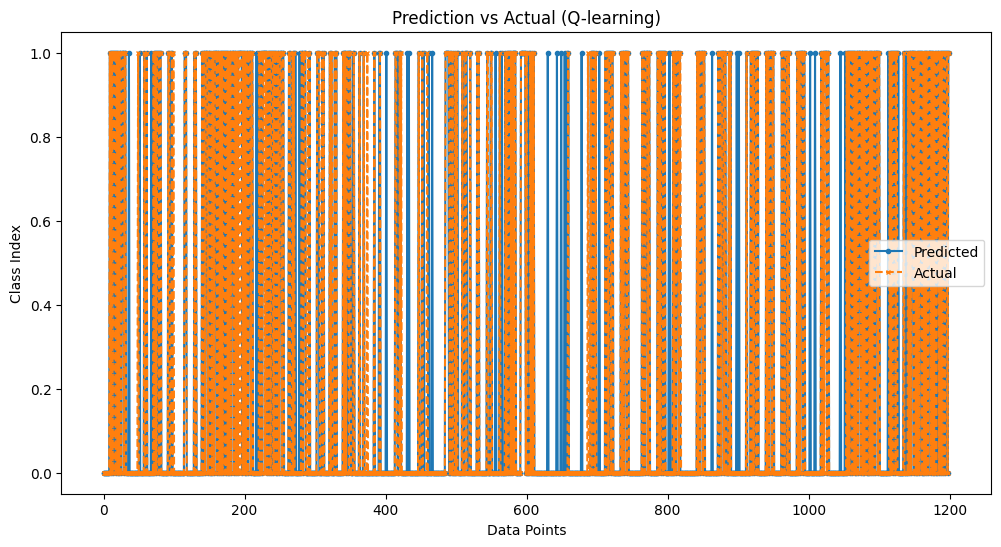

In [48]:
import matplotlib.pyplot as plt
import numpy as np

predicted_actions = []
actual_actions = []

for i in range(len(X)):
    state = X[i]

    predicted_index = q_learning_model.choose_action(state)
    actual_index = y.iloc[i]

    predicted_actions.append(predicted_index)
    actual_actions.append(actual_index)

# ==========================
# VẼ BIỂU ĐỒ
# ==========================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(predicted_actions))

ax.plot(x, predicted_actions, label='Predicted', marker='o', linestyle='-', markersize=3)
ax.plot(x, actual_actions, label='Actual', marker='x', linestyle='--', markersize=3)

ax.set_xlabel('Data Points')
ax.set_ylabel('Class Index')
ax.set_title('Prediction vs Actual (Q-learning)')
ax.legend()

plt.show()

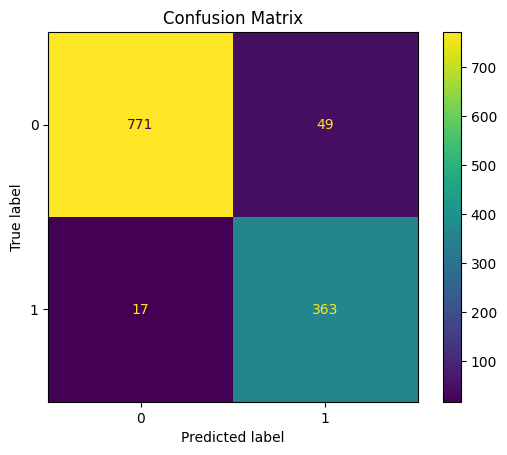

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(actual_actions, predicted_actions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [50]:
import pickle

# =========================================================
# LƯU MODEL + THÔNG TIN CẦN THIẾT
# =========================================================
save_data = {
    "model": q_learning_model,
    "mean": mean,
    "std": std,
    "label_to_index": label_to_index,
    "index_to_label": index_to_label,
    "drop_cols": drop_cols,
    "feature_columns": features.columns.tolist()
}

with open("q_learning_model.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("Đã lưu model thành công: q_learning_model.pkl")

Đã lưu model thành công: q_learning_model.pkl


In [54]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# 1. LOAD MODEL
# =========================================================
with open("/kaggle/working/q_learning_model.pkl", "rb") as f:
    saved = pickle.load(f)

q_learning_model = saved["model"]
feature_columns = saved["feature_columns"]
mean = saved["mean"]
std = saved["std"]
label_to_index = saved["label_to_index"]
index_to_label = saved["index_to_label"]
drop_cols = saved["drop_cols"]

# Nếu file model cũ không có key này thì dùng dict rỗng
categorical_mappings = saved.get("categorical_mappings", {})

print("Đã load model thành công")
print("Feature columns:", feature_columns)
print("Label mapping:", label_to_index)

# =========================================================
# 2. LOAD TEST DATA
# =========================================================
test_file = "/kaggle/input/datasets/n0g1ong/arpinggg/Spoofing_Test.csv"
df_test = pd.read_csv(test_file)

print("\nShape test:", df_test.shape)
print("Columns test:", df_test.columns.tolist())

df_test = pd.read_csv(test_file)

# Chuẩn hóa label cho khớp với model train hiện tại
df_test['Label'] = df_test['Label'].replace({
    'Malicious': 'Mallicious'
})
# =========================================================
# 3. TÁCH FEATURE VÀ LABEL
# =========================================================
features_test = df_test.drop(columns=drop_cols, errors='ignore').copy()

if 'Label' in df_test.columns:
    labels_test = df_test['Label'].copy()
    y_test = labels_test.map(label_to_index)
else:
    labels_test = None
    y_test = None

# =========================================================
# 4. THÊM CỘT THIẾU ĐỂ GIỐNG TRAIN
# =========================================================
for col in feature_columns:
    if col not in features_test.columns:
        features_test[col] = 0

# Chỉ giữ đúng cột và đúng thứ tự như train
features_test = features_test[feature_columns]

# =========================================================
# 5. XỬ LÝ CỘT OBJECT
# =========================================================
for col in features_test.columns:
    if features_test[col].dtype == 'object':
        # Nếu có mapping từ train thì dùng lại
        if col in categorical_mappings:
            mapping = categorical_mappings[col]
            features_test[col] = features_test[col].astype(str).map(mapping).fillna(-1)
        else:
            # Nếu model cũ không lưu mapping, factorize tạm thời
            features_test[col] = pd.factorize(features_test[col].astype(str))[0]

# =========================================================
# 6. XỬ LÝ NaN / inf
# =========================================================
features_test = features_test.replace([np.inf, -np.inf], np.nan)
features_test = features_test.fillna(0)

# =========================================================
# 7. CHUẨN HÓA THEO THAM SỐ TRAIN
# =========================================================
X_test = features_test.values.astype(float)

std_safe = std.copy()
std_safe[std_safe == 0] = 1

X_test = (X_test - mean) / std_safe

# =========================================================
# 8. DỰ ĐOÁN
# =========================================================
predictions_idx = []
predictions_label = []

for i in range(len(X_test)):
    state = X_test[i]
    pred_idx = q_learning_model.choose_action(state)
    predictions_idx.append(pred_idx)
    predictions_label.append(index_to_label[pred_idx])

df_result = df_test.copy()
df_result['Predicted_Label'] = predictions_label

# =========================================================
# 9. ĐÁNH GIÁ NẾU FILE TEST CÓ LABEL
# =========================================================
if y_test is not None:
    # bỏ các dòng có label lạ không map được
    valid_mask = y_test.notna()

    if valid_mask.sum() > 0:
        y_test_valid = y_test[valid_mask].astype(int)
        predictions_valid = np.array(predictions_idx)[valid_mask]

        acc = accuracy_score(y_test_valid, predictions_valid)
        print(f"\nTest Accuracy: {acc * 100:.2f}%")

        print("\nClassification Report:")
        print(classification_report(
            y_test_valid,
            predictions_valid,
            target_names=[index_to_label[i] for i in sorted(index_to_label.keys())]
        ))

        print("\nConfusion Matrix:")
        print(confusion_matrix(y_test_valid, predictions_valid))
    else:
        print("\nLabel trong file test không khớp với label đã train, chỉ xuất dự đoán.")
else:
    print("\nFile test không có cột Label, chỉ xuất dự đoán.")

# =========================================================
# 10. XUẤT KẾT QUẢ
# =========================================================
output_file = "/kaggle/working/Spoofing_Test_Predicted.csv"
df_result.to_csv(output_file, index=False)

print(f"\nĐã lưu kết quả dự đoán vào: {output_file}")
print("\n20 dòng đầu:")
if 'Label' in df_result.columns:
    print(df_result[['Label', 'Predicted_Label']].head(20))
else:
    print(df_result.head(20))

Đã load model thành công
Feature columns: ['Protocol', 'Length', 'Info']
Label mapping: {'Benign': 0, 'Mallicious': 1}

Shape test: (1202, 8)
Columns test: ['No.', 'Time', 'Length', 'Source', 'Destination', 'Protocol', 'Label', 'Info']

Test Accuracy: 34.53%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.33      0.94      0.49       401
  Mallicious       0.61      0.05      0.09       801

    accuracy                           0.35      1202
   macro avg       0.47      0.49      0.29      1202
weighted avg       0.52      0.35      0.22      1202


Confusion Matrix:
[[376  25]
 [762  39]]

Đã lưu kết quả dự đoán vào: /kaggle/working/Spoofing_Test_Predicted.csv

20 dòng đầu:
         Label Predicted_Label
0       Benign          Benign
1   Mallicious          Benign
2       Benign          Benign
3   Mallicious          Benign
4   Mallicious          Benign
5       Benign          Benign
6   Mallicious          Benign
7   Malliciou

In [20]:
import pickle

save_data = {
    "model": q_learning_model,
    "feature_columns": feature_columns,
    "mean": mean,
    "std": std,
    "label_to_index": label_to_index,
    "index_to_label": index_to_label
}

with open("/kaggle/working/q_learning_spoof_feature_model.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("Đã lưu model: /kaggle/working/q_learning_spoof_feature_model.pkl")

Đã lưu model: /kaggle/working/q_learning_spoof_feature_model.pkl


In [27]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# 1. LOAD MODEL
# =========================================================
with open("/kaggle/working/q_learning_spoof_feature_model.pkl", "rb") as f:
    saved = pickle.load(f)

q_learning_model = saved["model"]
feature_columns = saved["feature_columns"]
mean = saved["mean"]
std = saved["std"]
label_to_index = saved["label_to_index"]
index_to_label = saved["index_to_label"]

print("Đã load model thành công")
print("Feature columns:", feature_columns)
print("Label mapping:", label_to_index)

# =========================================================
# 2. LOAD TEST
# =========================================================
test_file = "/kaggle/working/Spoofing_Testing.csv"
df_test = pd.read_csv(test_file)

df_test['Label'] = df_test['Label'].replace({
    'Malicious': 'Mallicious'
})

print("\nShape test:", df_test.shape)
print("Columns test:", df_test.columns.tolist())

# =========================================================
# 3. BUILD FEATURE TEST
# =========================================================
features_test, _ = build_spoofing_features(df_test)

# đảm bảo đúng cột
for col in feature_columns:
    if col not in features_test.columns:
        features_test[col] = 0

features_test = features_test[feature_columns]

X_test = features_test.values.astype(float)

std_safe = std.copy()
std_safe[std_safe == 0] = 1

X_test = (X_test - mean) / std_safe

# =========================================================
# 4. LABEL TEST
# =========================================================
y_test = df_test['Label'].map(label_to_index)

# =========================================================
# 5. PREDICT
# =========================================================
predictions_idx = []
predictions_label = []

for i in range(len(X_test)):
    state = X_test[i]
    pred_idx = q_learning_model.choose_action(state)
    predictions_idx.append(pred_idx)
    predictions_label.append(index_to_label[pred_idx])

# =========================================================
# 6. EVALUATE
# =========================================================
acc = accuracy_score(y_test, predictions_idx)
print(f"\nTest Accuracy: {acc * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    predictions_idx,
    target_names=[index_to_label[i] for i in sorted(index_to_label.keys())]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions_idx))

# =========================================================
# 7. SAVE RESULT
# =========================================================
df_result = df_test.copy()
df_result['Predicted_Label'] = predictions_label

output_file = "/kaggle/working/Spoofing_Test_Predicted_Feature.csv"
df_result.to_csv(output_file, index=False)

print(f"\nĐã lưu kết quả: {output_file}")
print(df_result[['Label', 'Predicted_Label']].head(20))

Đã load model thành công
Feature columns: ['Length', 'is_arp', 'is_tcp', 'is_udp', 'is_icmp', 'is_request', 'is_reply', 'has_duplicate_ip', 'has_reply_word', 'has_request_word', 'has_broadcast', 'has_unicast', 'has_tell', 'arp_spoof_pattern', 'ip_count_in_info', 'source_change_count', 'destination_change_count', 'source_freq', 'destination_freq', 'first_ip_code', 'second_ip_code']
Label mapping: {'Benign': 0, 'Mallicious': 1}

Shape test: (1202, 8)
Columns test: ['No.', 'Time', 'Length', 'Source', 'Destination', 'Protocol', 'Label', 'Info']

Test Accuracy: 35.19%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.33      0.95      0.49       401
  Mallicious       0.67      0.05      0.10       801

    accuracy                           0.35      1202
   macro avg       0.50      0.50      0.30      1202
weighted avg       0.56      0.35      0.23      1202


Confusion Matrix:
[[380  21]
 [758  43]]

Đã lưu kết quả: /kaggle/working/Spoo

# Final

In [48]:
import pandas as pd
import numpy as np
import re

def build_spoofing_features(df):
    df = df.copy()

    # =========================================================
    # 0. CHUẨN HÓA CỘT
    # =========================================================
    for col in ['Protocol', 'Info', 'Source', 'Destination']:
        if col not in df.columns:
            df[col] = ''
        df[col] = df[col].astype(str).fillna('')

    info_lower = df['Info'].str.lower()
    proto_lower = df['Protocol'].str.lower()

    # =========================================================
    # 1. FEATURE CƠ BẢN
    # =========================================================
    df['Length'] = pd.to_numeric(df.get('Length', 0), errors='coerce').fillna(0)

    df['is_arp'] = proto_lower.str.contains('arp', regex=False).astype(int)
    df['is_tcp'] = proto_lower.str.contains('tcp', regex=False).astype(int)
    df['is_udp'] = proto_lower.str.contains('udp', regex=False).astype(int)
    df['is_icmp'] = proto_lower.str.contains('icmp', regex=False).astype(int)

    # =========================================================
    # 2. FEATURE TỪ INFO (vectorized - nhanh)
    # =========================================================
    df['is_request'] = info_lower.str.contains('who has', regex=False).astype(int)
    df['is_reply'] = info_lower.str.contains('is at', regex=False).astype(int)
    df['has_duplicate_ip'] = info_lower.str.contains('duplicate use of', regex=False).astype(int)
    df['has_reply_word'] = info_lower.str.contains(r'\breply\b').astype(int)
    df['has_request_word'] = info_lower.str.contains(r'\brequest\b').astype(int)
    df['has_broadcast'] = info_lower.str.contains('broadcast', regex=False).astype(int)
    df['has_unicast'] = info_lower.str.contains('unicast', regex=False).astype(int)
    df['has_tell'] = info_lower.str.contains('tell', regex=False).astype(int)

    # Pattern ARP spoof
    df['arp_spoof_pattern'] = (
        (df['is_arp'] == 1) &
        ((df['is_reply'] == 1) | (df['has_duplicate_ip'] == 1))
    ).astype(int)

    # =========================================================
    # 3. TRÍCH IP (FAST - không dùng apply)
    # =========================================================
    ip_pattern = r'(\d{1,3}(?:\.\d{1,3}){3})'
    extracted_ips = df['Info'].str.findall(ip_pattern)

    df['ip_count_in_info'] = extracted_ips.str.len().fillna(0)

    # Không encode IP trực tiếp (tránh bug deploy)
    df['has_multiple_ips'] = (df['ip_count_in_info'] > 1).astype(int)

    # =========================================================
    # 4. CHANGE FEATURE (fix logic)
    # =========================================================
    df['source_changed'] = (df['Source'] != df['Source'].shift()).astype(int)
    df['destination_changed'] = (df['Destination'] != df['Destination'].shift()).astype(int)

    # =========================================================
    # 5. FREQUENCY FEATURE
    # =========================================================
    src_counts = df['Source'].value_counts()
    dst_counts = df['Destination'].value_counts()

    df['source_freq'] = df['Source'].map(src_counts).fillna(0)
    df['destination_freq'] = df['Destination'].map(dst_counts).fillna(0)

    # =========================================================
    # 6. TIME FEATURE (nếu có)
    # =========================================================
    if 'Time' in df.columns:
        df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
        df['time_diff'] = df['Time'].diff().fillna(0)
    else:
        df['time_diff'] = 0

    # =========================================================
    # 7. CHỌN FEATURE CUỐI
    # =========================================================
    feature_cols = [
        'Length',
        'is_arp', 'is_tcp', 'is_udp', 'is_icmp',
        'is_request', 'is_reply',
        'has_duplicate_ip', 'has_reply_word', 'has_request_word',
        'has_broadcast', 'has_unicast', 'has_tell',
        'arp_spoof_pattern',
        'ip_count_in_info', 'has_multiple_ips',
        'source_changed', 'destination_changed',
        'source_freq', 'destination_freq',
        'time_diff'
    ]

    feature_df = df[feature_cols].copy()
    feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return feature_df, feature_cols

In [11]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [12]:
# Load dataset
df = pd.read_csv("/kaggle/input/datasets/n0g1ong/arpinggg/Spoofing_Dataset.csv")

# Fix label typo
df['Label'] = df['Label'].replace({'Malicious': 'Mallicious'})

# Build feature
X_df, feature_cols = build_spoofing_features(df)

# Label
y = df['Label']

In [13]:
label_to_index = {
    'Benign': 0,
    'Mallicious': 1
}

index_to_label = {v: k for k, v in label_to_index.items()}

y = df['Label'].map(label_to_index)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df.values, y.values,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [17]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=index_to_label.values()))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9708333333333333

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98       164
  Mallicious       0.95      0.96      0.95        76

    accuracy                           0.97       240
   macro avg       0.96      0.97      0.97       240
weighted avg       0.97      0.97      0.97       240


Confusion Matrix:
[[160   4]
 [  3  73]]


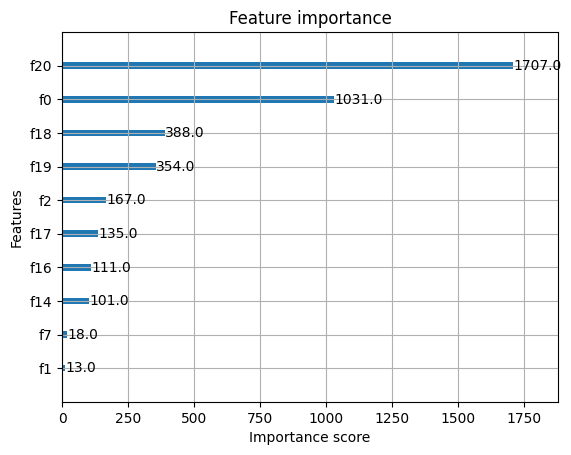

In [18]:
import matplotlib.pyplot as plt

xgb.plot_importance(model, max_num_features=10)
plt.show()

In [25]:
# Save model
model.save_model("/kaggle/working/xgb_model.json")

# Save label map
import pickle
pickle.dump(label_to_index, open("/kaggle/working/label_map.pkl", "wb"))

# Save feature columns (rất quan trọng)
pickle.dump(feature_cols, open("/kaggle/working/feature_cols.pkl", "wb"))

print("Saved model successfully!")

Saved model successfully!


In [43]:
import xgboost as xgb
import pickle

# Load model
model = xgb.XGBClassifier()
model.load_model("/kaggle/working/xgb_model.json")

# Load label map
label_to_index = pickle.load(open("/kaggle/working/label_map.pkl", "rb"))
index_to_label = {v: k for k, v in label_to_index.items()}

# Load feature columns
feature_cols = pickle.load(open("/kaggle/working/feature_cols.pkl", "rb"))

In [44]:
df_test = pd.read_csv("/kaggle/working/Spoofing_Testing.csv")

In [45]:
X_test_df, _ = build_spoofing_features(df_test)

# Đảm bảo đúng thứ tự cột như lúc train
X_test_df = X_test_df[feature_cols]

In [41]:
y_pred = model.predict(X_test_df.values)

# Decode label
pred_labels = [index_to_label[i] for i in y_pred]

df_test['Prediction'] = pred_labels

print(df_test[['Prediction']].head())

   Prediction
0      Benign
1  Mallicious
2      Benign
3  Mallicious
4  Mallicious


In [50]:
import pandas as pd
import xgboost as xgb
import pickle


# Load model
model = xgb.XGBClassifier()
model.load_model("/kaggle/working/xgb_model.json")

label_to_index = pickle.load(open("/kaggle/working/label_map.pkl", "rb"))
index_to_label = {v: k for k, v in label_to_index.items()}

feature_cols = pickle.load(open("/kaggle/working/feature_cols.pkl", "rb"))

# Load test
df_test = pd.read_csv("/kaggle/working/Spoofing_Testing.csv")

# Feature
X_test_df, _ = build_spoofing_features(df_test)
X_test_df = X_test_df[feature_cols]

# Predict
y_pred = model.predict(X_test_df.values)
pred_labels = [index_to_label[i] for i in y_pred]

df_test['Prediction'] = pred_labels

print(df_test[['Prediction']].head())

   Prediction
0      Benign
1  Mallicious
2      Benign
3  Mallicious
4  Mallicious


In [51]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# TÍNH ACC (nếu có label thật)
# =========================================================
if 'Label' in df_test.columns:
    
    # Encode label giống lúc train
    y_true = df_test['Label'].map(label_to_index)

    # Drop NaN (nếu có label lạ)
    valid_idx = y_true.notna()
    y_true = y_true[valid_idx]
    y_pred_eval = y_pred[valid_idx]

    acc = accuracy_score(y_true, y_pred_eval)
    print("\nAccuracy:", acc)

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred_eval,
        target_names=list(index_to_label.values())
    ))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred_eval))

else:
    print("\n⚠️ Không có cột Label → chỉ predict, không tính ACC")


Accuracy: 0.997504159733777

Classification Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       401
  Mallicious       1.00      1.00      1.00       801

    accuracy                           1.00      1202
   macro avg       1.00      1.00      1.00      1202
weighted avg       1.00      1.00      1.00      1202


Confusion Matrix:
[[400   1]
 [  2 799]]
